In [1]:
# 1. Tải thư viện
!pip install kagglehub transformers datasets scikit-learn matplotlib seaborn wordcloud nltk tqdm nlpaug --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 23.7 MB/s eta 0:00:00


In [2]:
# 2. Global Configuration
USE_PRECOMPUTED_FEATURES = True
RUN_FEATURE_EXTRACTION = False
CREATE_FEATURE_ZIP = False
DOWNLOAD_FEATURE_ZIP = False
RUN_BERT_EMBEDDING = False

In [3]:
# 3. Import thư viện ban đầu
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from wordcloud import WordCloud

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import re

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [4]:
os.makedirs("features", exist_ok=True)
os.makedirs("modules", exist_ok=True)

In [5]:
# 4. Modules Utils.py
%%writefile modules/utils.py
def load_ag_news(path):
    """
    Đọc dữ liệu AG News, xử lý header và ghép title + description thành cột text.

    Input:
        path: thư mục chứa train.csv và test.csv

    Output:
        train_df, test_df
    """
    train_path = os.path.join(path, "train.csv")
    test_path = os.path.join(path, "test.csv")

    train_df = pd.read_csv(
        train_path,
        header=0,
        names=["label", "title", "description"]
    )

    test_df = pd.read_csv(
        test_path,
        header=0,
        names=["label", "title", "description"]
    )

    for df in [train_df, test_df]:
        # Đảm bảo label là kiểu số
        df["label"] = pd.to_numeric(df["label"], errors="coerce")

        # Loại bỏ dòng lỗi label
        df.dropna(subset=["label"], inplace=True)

        # Chuyển nhãn từ [1, 4] về [0, 3]
        df["label"] = df["label"].astype(int) - 1

        # Ghép title + description thành text
        df["text"] = df["title"].fillna("") + " " + df["description"].fillna("")

        # Reset index sau khi drop
        df.reset_index(drop=True, inplace=True)

    return train_df, test_df


def plot_eda(df, label_names):
    """
    Vẽ biểu đồ phân phối nhãn và phân phối độ dài văn bản.
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Phân phối nhãn
    sns.countplot(x=df["label"], ax=axes[0])
    axes[0].set_xticks(range(len(label_names)))
    axes[0].set_xticklabels(label_names, rotation=0)
    axes[0].set_title("Class Distribution")
    axes[0].set_xlabel("Class")
    axes[0].set_ylabel("Count")

    # Phân phối độ dài văn bản
    text_len = df["text"].apply(lambda x: len(str(x).split()))
    sns.histplot(text_len, bins=50, ax=axes[1], kde=True)
    axes[1].set_title("Text Length Distribution")
    axes[1].set_xlabel("Number of words")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()
    plt.show()


def plot_wordcloud(df, label_idx, label_name, sample_size=2000):
    """
    Vẽ WordCloud cho một lớp cụ thể.
    """
    class_texts = df[df["label"] == label_idx]["text"]

    if len(class_texts) == 0:
        print(f"No text found for label {label_idx}: {label_name}")
        return

    sample_n = min(sample_size, len(class_texts))
    text = " ".join(class_texts.sample(sample_n, random_state=42).astype(str))

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"WordCloud for class: {label_name}")
    plt.axis("off")
    plt.show()

Writing modules/utils.py


In [6]:
# 5. Modules preprocessing.py
%%writefile modules/preprocessing.py
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer


class TextPreprocessor:
    """
    Text preprocessing module for text classification.

    Steps:
    1. Lowercase
    2. Remove non-letter characters
    3. Normalize whitespace
    4. Tokenize by whitespace
    5. Remove stopwords
    6. Optional stemming
    """

    def __init__(self, use_stemming=False, remove_stopwords=True):
        self.use_stemming = use_stemming
        self.remove_stopwords = remove_stopwords

        # Download stopwords if missing
        try:
            stopwords.words("english")
        except LookupError:
            nltk.download("stopwords")

        self.stop_words = set(stopwords.words("english"))
        self.stemmer = PorterStemmer()

    def clean_text(self, text):
        text = str(text)

        # 1. Lowercase
        text = text.lower()

        # 2. Remove numbers, punctuation, special characters
        text = re.sub(r"[^a-zA-Z\s]", " ", text)

        # 3. Normalize whitespace
        text = re.sub(r"\s+", " ", text).strip()

        # 4. Tokenization by whitespace
        tokens = text.split()

        # 5. Remove short tokens
        tokens = [w for w in tokens if len(w) >= 2]

        # 6. Remove stopwords
        if self.remove_stopwords:
            tokens = [w for w in tokens if w not in self.stop_words]

        # 7. Optional stemming
        if self.use_stemming:
            tokens = [self.stemmer.stem(w) for w in tokens]

        return " ".join(tokens)

    def transform(self, texts):
        return [self.clean_text(text) for text in texts]

Writing modules/preprocessing.py


In [7]:
%%writefile modules/feature_extraction.py
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Optional dependency: gensim is only needed for Word2Vec
try:
    from gensim.models import Word2Vec
except ImportError:
    Word2Vec = None

import torch
from transformers import BertTokenizer, BertModel


def extract_traditional(train_texts, test_texts, method="tfidf", max_features=5000):
    if method == "bow":
        vectorizer = CountVectorizer(max_features=max_features, ngram_range=(1, 2))
    else:
        vectorizer = TfidfVectorizer(max_features=max_features, ngram_range=(1, 2))

    X_train = vectorizer.fit_transform(train_texts).toarray()
    X_test = vectorizer.transform(test_texts).toarray()

    return X_train, X_test


def extract_word2vec(train_tokens, test_tokens, vector_size=100):
    if Word2Vec is None:
        raise ImportError(
            "gensim is not installed. Please install it with: !pip install gensim"
        )

    model = Word2Vec(
        sentences=train_tokens,
        vector_size=vector_size,
        window=5,
        min_count=1,
        workers=4
    )

    def get_avg_vector(tokens):
        vecs = [model.wv[w] for w in tokens if w in model.wv]
        return np.mean(vecs, axis=0) if vecs else np.zeros(vector_size)

    X_train = np.array([get_avg_vector(t) for t in train_tokens])
    X_test = np.array([get_avg_vector(t) for t in test_tokens])

    return X_train, X_test


def extract_bert(texts, batch_size=32):
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    model = BertModel.from_pretrained("bert-base-uncased")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    all_embeddings = []

    texts = list(texts)

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        inputs = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = model(**inputs)
            embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            all_embeddings.append(embeddings)

    return np.vstack(all_embeddings)

Writing modules/feature_extraction.py


In [8]:
%%writefile modules/models.py
import time
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)


def train_evaluate(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    name="Model",
    feature_name="Feature",
    label_names=None,
    verbose=True
):
    """
    Train và evaluate một model.

    Output:
        result: dict chứa accuracy, precision, recall, f1, thời gian train
        report: classification_report dạng dict
        y_pred: nhãn dự đoán
    """
    start_time = time.time()

    model.fit(X_train, y_train)

    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    macro_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)

    report = classification_report(
        y_test,
        y_pred,
        target_names=label_names,
        output_dict=True,
        zero_division=0
    )

    result = {
        "model": name,
        "feature": feature_name,
        "accuracy": acc,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "train_time_sec": train_time
    }

    if verbose:
        print(f"--- {name} + {feature_name} Results ---")
        print(f"Accuracy     : {acc:.4f}")
        print(f"Macro-F1     : {macro_f1:.4f}")
        print(f"Weighted-F1  : {weighted_f1:.4f}")
        print(f"Train time   : {train_time:.2f} sec")

    return result, report, y_pred


def results_to_dataframe(results):
    """
    Chuyển list kết quả thành DataFrame và sort theo accuracy.
    """
    df = pd.DataFrame(results)

    if "accuracy" in df.columns:
        df = df.sort_values(by="accuracy", ascending=False).reset_index(drop=True)

    return df

Writing modules/models.py


In [9]:
import sys
from pathlib import Path

sys.path.append("/content")

from modules.utils import load_ag_news, plot_eda, plot_wordcloud
from modules.preprocessing import TextPreprocessor
from modules.feature_extraction import extract_traditional, extract_word2vec, extract_bert
from modules.models import train_evaluate, results_to_dataframe


print("All modules imported successfully.")

All modules imported successfully.


In [10]:
import kagglehub

try:
    path = kagglehub.dataset_download("amananandrai/ag-news-classification-dataset")
    print("Dataset path:", path)
except Exception as e:
    print("KaggleHub failed, fallback download...")
    !wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/train.csv
    !wget https://raw.githubusercontent.com/mhjabreel/CharCnn_Keras/master/data/ag_news_csv/test.csv
    path = "./"

100%|██████████| 11.4M/11.4M [00:01<00:00, 6.91MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/amananandrai/ag-news-classification-dataset/versions/2


In [11]:
# Xác định path
train_path = os.path.join(path, "train.csv") if os.path.exists(os.path.join(path, "train.csv")) else "train.csv"
test_path = os.path.join(path, "test.csv") if os.path.exists(os.path.join(path, "test.csv")) else "test.csv"

# Đọc dữ liệu (KHÔNG header=None để tránh lỗi Class Index)
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Đổi tên cột cho thống nhất
df_train.columns = ["label", "title", "description"]
df_test.columns = ["label", "title", "description"]

# 🔥 Loại bỏ các dòng lỗi (ví dụ "Class Index")
df_train = df_train[df_train["label"].apply(lambda x: str(x).isdigit())]
df_test = df_test[df_test["label"].apply(lambda x: str(x).isdigit())]

# Convert label sang int
df_train["label"] = df_train["label"].astype(int)
df_test["label"] = df_test["label"].astype(int)

# Mapping label → tên class
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

df_train["label_name"] = df_train["label"].map(label_map)
df_test["label_name"] = df_test["label"].map(label_map)

# Reset index cho sạch
df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

# Kiểm tra
print("Unique labels:", np.unique(df_train["label"]))
print(df_train.head())

Unique labels: [1 2 3 4]
   label                                              title  \
0      3  Wall St. Bears Claw Back Into the Black (Reuters)   
1      3  Carlyle Looks Toward Commercial Aerospace (Reu...   
2      3    Oil and Economy Cloud Stocks' Outlook (Reuters)   
3      3  Iraq Halts Oil Exports from Main Southern Pipe...   
4      3  Oil prices soar to all-time record, posing new...   

                                         description label_name  
0  Reuters - Short-sellers, Wall Street's dwindli...   Business  
1  Reuters - Private investment firm Carlyle Grou...   Business  
2  Reuters - Soaring crude prices plus worries\ab...   Business  
3  Reuters - Authorities have halted oil export\f...   Business  
4  AFP - Tearaway world oil prices, toppling reco...   Business  


📊 EDA

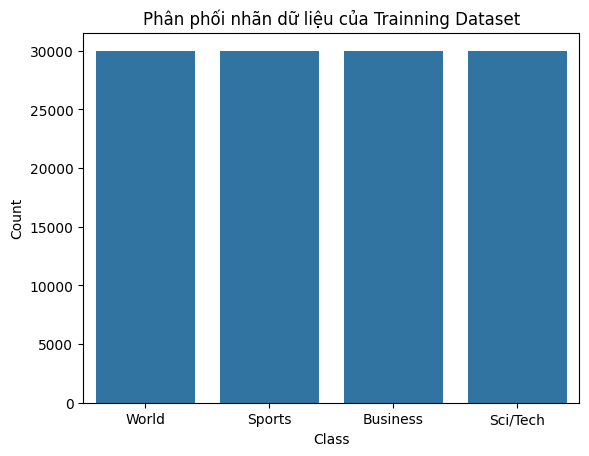

In [12]:
sns.countplot(
    x="label_name",
    data=df_train,
    order=list(label_map.values())
)

plt.title("Phân phối nhãn dữ liệu của Trainning Dataset")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Text Length Statistics - Number of Words


,word_count
count,120000.000000
mean,37.844617
std,10.088702
min,4.000000
25%,32.000000
50%,37.000000
75%,43.000000
95%,53.000000
99%,70.000000
max,177.000000


Text Length Statistics by Class


,count,min,mean,median,max,std
label_name,,,,,,
World,30000,9,38.88,39.0,145,10.32
Sports,30000,4,37.77,37.0,151,8.88
Business,30000,8,37.54,37.0,134,8.12
Sci/Tech,30000,8,37.19,36.0,177,12.42


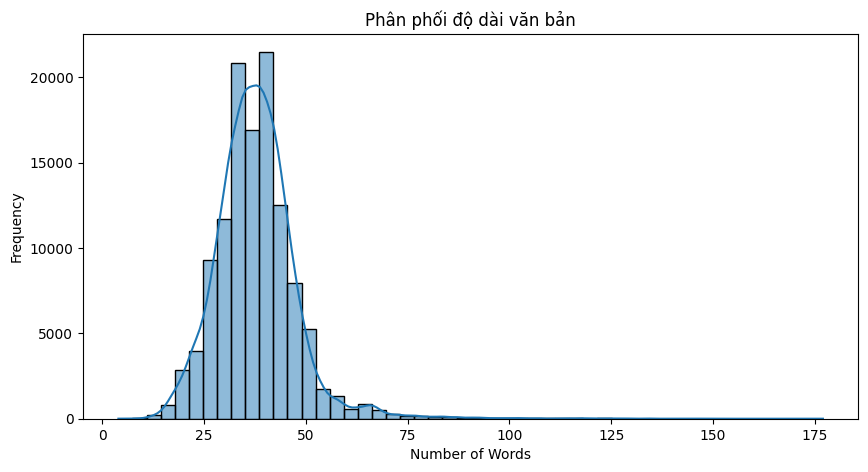

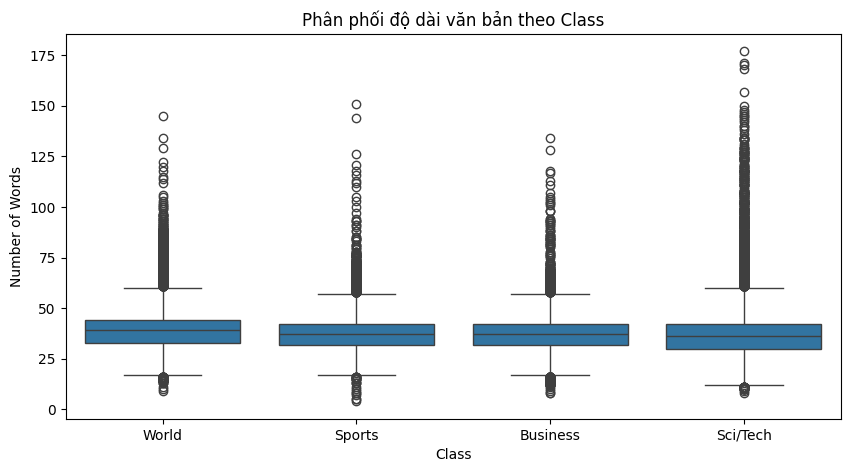

In [13]:
# =========================
# EDA: Text Length Statistics
# =========================

# Nếu chưa có cột text thì ghép title + description
if "text" not in df_train.columns:
    df_train["text"] = df_train["title"].fillna("") + " " + df_train["description"].fillna("")

# Tính số từ trong mỗi văn bản
df_train["word_count"] = df_train["text"].apply(lambda x: len(str(x).split()))

# Bảng thống kê tổng quát
length_stats = df_train["word_count"].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])

print("Text Length Statistics - Number of Words")
display(length_stats.to_frame(name="word_count"))

# Thống kê độ dài theo từng class
length_by_class = (
    df_train
    .groupby("label_name")["word_count"]
    .agg(["count", "min", "mean", "median", "max", "std"])
    .round(2)
    .reindex(list(label_map.values()))
)

print("Text Length Statistics by Class")
display(length_by_class)

# Vẽ biểu đồ phân phối độ dài văn bản
plt.figure(figsize=(10, 5))
sns.histplot(df_train["word_count"], bins=50, kde=True)

plt.title("Phân phối độ dài văn bản")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

# Vẽ boxplot để so sánh độ dài văn bản giữa các class
plt.figure(figsize=(10, 5))
sns.boxplot(
    x="label_name",
    y="word_count",
    data=df_train,
    order=list(label_map.values())
)

plt.title("Phân phối độ dài văn bản theo Class")
plt.xlabel("Class")
plt.ylabel("Number of Words")
plt.show()

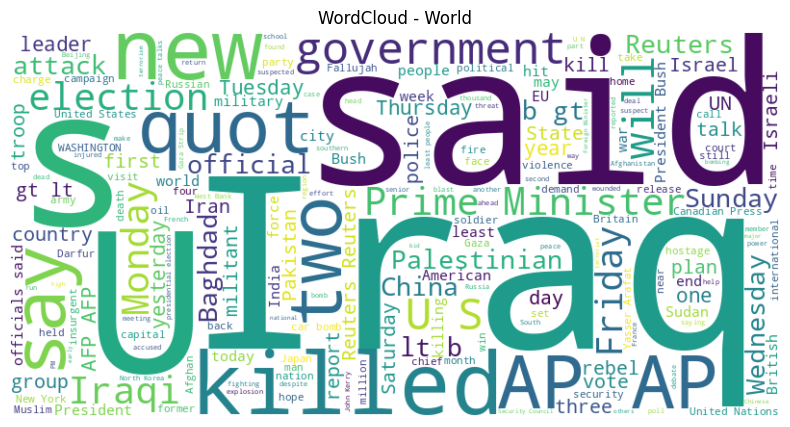

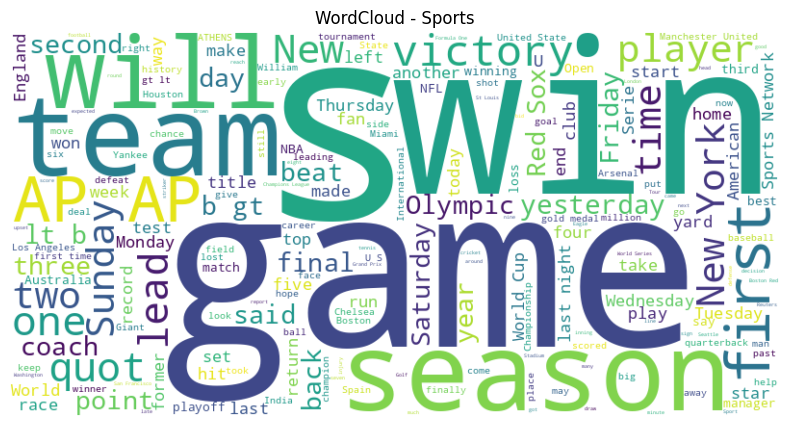

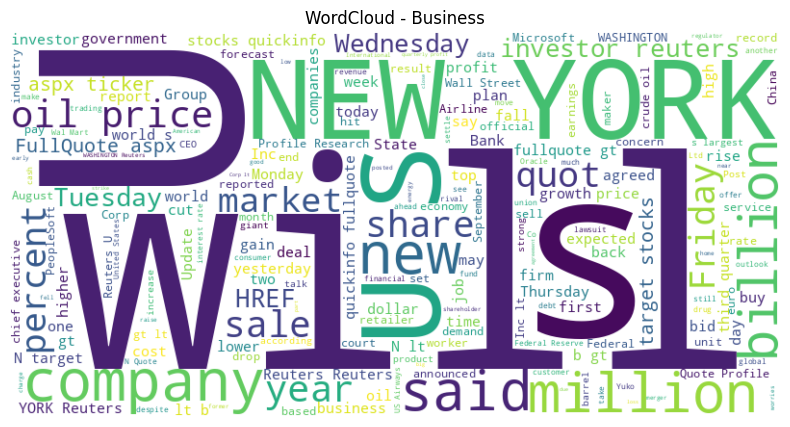

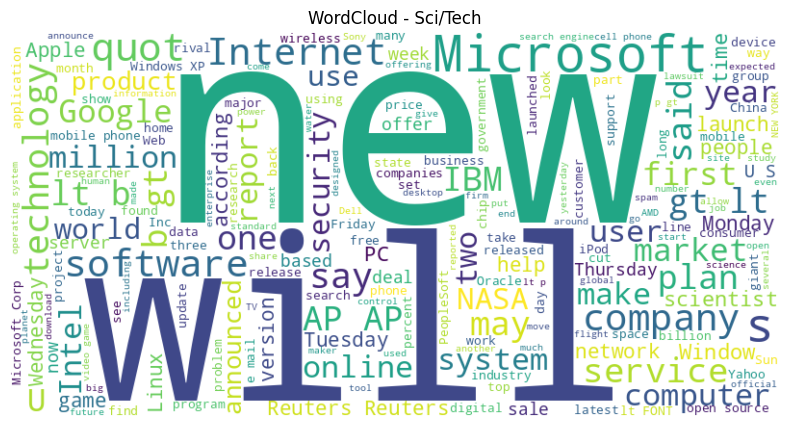

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ưu tiên dùng cột đã xử lý sạch
if "clean" in df_train.columns:
    text_col = "clean"
elif "text" in df_train.columns:
    text_col = "text"
else:
    text_col = "description"

for class_name in label_map.values():
    class_df = df_train[df_train["label_name"] == class_name]

    if len(class_df) == 0:
        continue

    sample_n = min(3000, len(class_df))
    text = " ".join(class_df[text_col].sample(sample_n, random_state=42).astype(str))

    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        colormap="viridis",
        random_state=42
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.title(f"WordCloud - {class_name}")
    plt.axis("off")
    plt.show()


,word,frequency
0,the,205468
1,to,120734
2,of,98647
3,in,96424
4,and,69668
5,on,57660
6,for,50674
7,that,28168
8,with,26809
9,as,25376


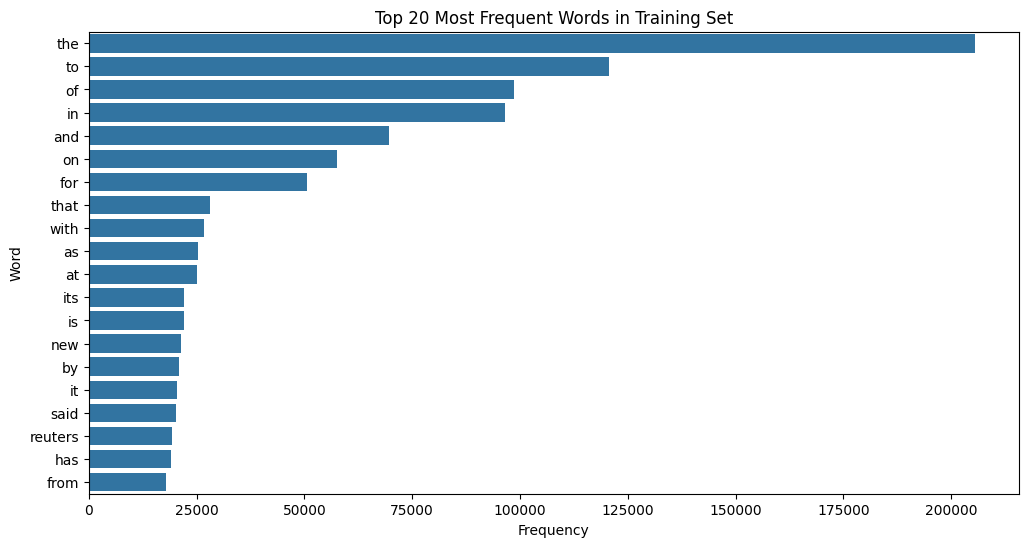

In [15]:
# Tần suất từ trên toàn bộ Dataset
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Chọn cột text để phân tích
if "clean" in df_train.columns:
    text_col = "clean"
elif "text" in df_train.columns:
    text_col = "text"
else:
    text_col = "description"

# Gộp toàn bộ text
all_text = " ".join(df_train[text_col].astype(str))

# Token hóa đơn giản
tokens = re.findall(r"\b[a-zA-Z]{2,}\b", all_text.lower())

# Đếm tần suất từ
word_freq = Counter(tokens)

# Lấy top 20 từ phổ biến nhất
top_words = word_freq.most_common(20)

top_words_df = pd.DataFrame(top_words, columns=["word", "frequency"])

display(top_words_df)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_words_df,
    x="frequency",
    y="word"
)

plt.title("Top 20 Most Frequent Words in Training Set")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

Top 10 words for class: World


,word,frequency
0,the,49038
1,in,32216
2,to,31138
3,of,28981
4,and,17655
5,on,16208
6,for,11638
7,said,7745
8,that,6805
9,at,6271


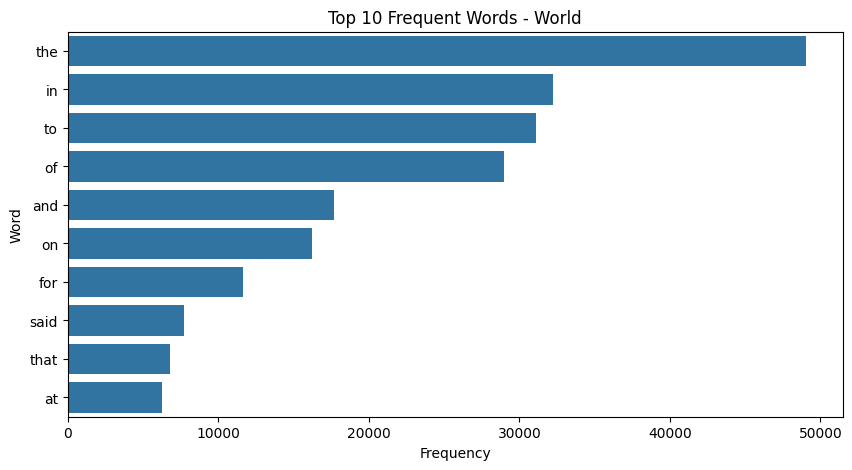

Top 10 words for class: Sports


,word,frequency
0,the,63383
1,to,27672
2,in,24050
3,of,20390
4,and,15853
5,for,13903
6,on,12353
7,at,9358
8,with,8409
9,his,7851


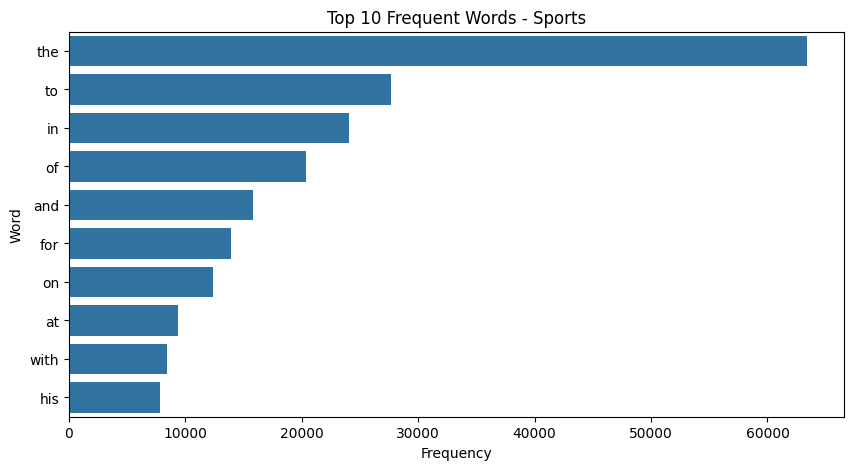

Top 10 words for class: Business


,word,frequency
0,the,44820
1,to,30221
2,of,22781
3,in,22300
4,and,17190
5,on,16780
6,for,12165
7,its,9567
8,reuters,8717
9,as,8299


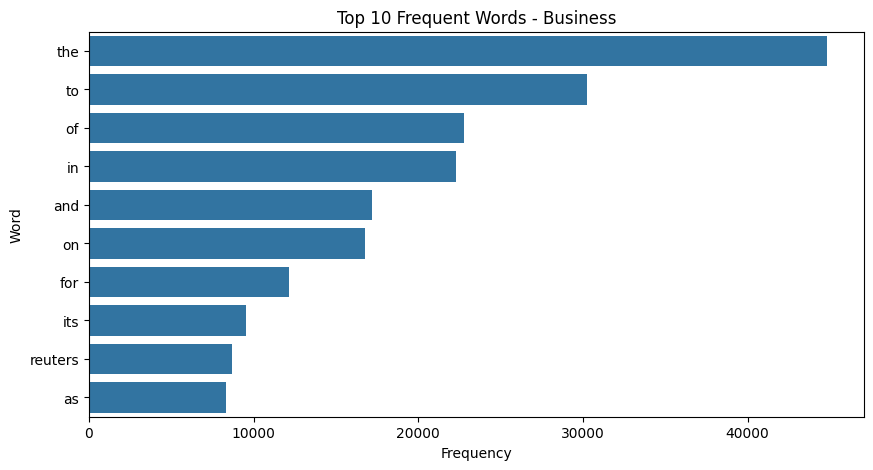

Top 10 words for class: Sci/Tech


,word,frequency
0,the,48227
1,to,31703
2,of,26495
3,and,18970
4,in,17858
5,for,12968
6,on,12319
7,that,9464
8,is,7969
9,its,7857


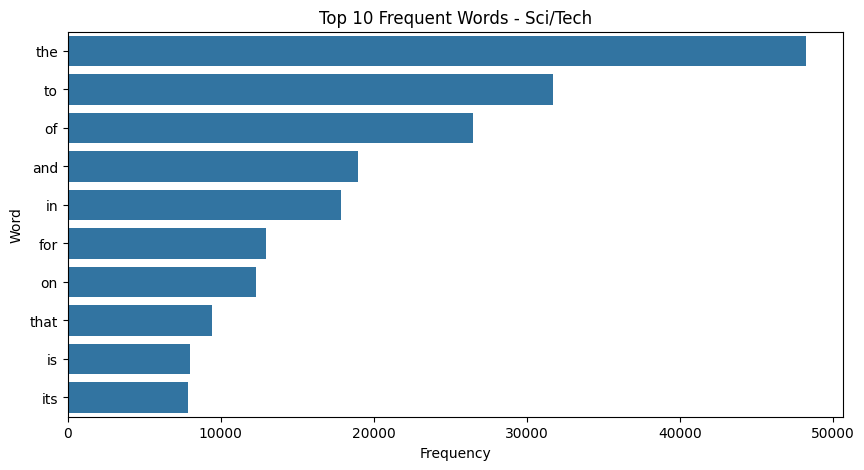

In [16]:
from collections import Counter
import re

top_k = 10

for class_name in label_map.values():
    class_df = df_train[df_train["label_name"] == class_name]

    if len(class_df) == 0:
        continue

    class_text = " ".join(class_df[text_col].astype(str))
    tokens = re.findall(r"\b[a-zA-Z]{2,}\b", class_text.lower())

    word_freq = Counter(tokens)
    top_words = word_freq.most_common(top_k)

    top_words_df = pd.DataFrame(top_words, columns=["word", "frequency"])

    print(f"Top {top_k} words for class: {class_name}")
    display(top_words_df)

    plt.figure(figsize=(10, 5))
    sns.barplot(
        data=top_words_df,
        x="frequency",
        y="word"
    )

    plt.title(f"Top {top_k} Frequent Words - {class_name}")
    plt.xlabel("Frequency")
    plt.ylabel("Word")
    plt.show()

In [17]:
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

print("\nMissing values in training dataset:")
display(df_train.isnull().sum())

print("\nMissing values in testing dataset:")
display(df_test.isnull().sum())

print("\nDuplicate rows in train:", df_train.duplicated().sum())
print("Duplicate rows in test:", df_test.duplicated().sum())

Train shape: (120000, 6)
Test shape: (7600, 4)

Missing values in training dataset:


,0
label,0
title,0
description,0
label_name,0
text,0
word_count,0



Missing values in testing dataset:


,0
label,0
title,0
description,0
label_name,0



Duplicate rows in train: 0
Duplicate rows in test: 0


🧹 **Tiền xử lý**

In [18]:
# =========================
# Text Preprocessing
# =========================

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import modules.preprocessing as preprocessing_module

# Đảm bảo NLTK stopwords có sẵn
try:
    stopwords.words("english")
except LookupError:
    nltk.download("stopwords")

# Inject đầy đủ dependency vào namespace của modules.preprocessing
# Không sửa file module, chỉ sửa runtime namespace
preprocessing_module.re = re
preprocessing_module.nltk = nltk
preprocessing_module.stopwords = stopwords
preprocessing_module.PorterStemmer = PorterStemmer

TextPreprocessor = preprocessing_module.TextPreprocessor

PREPROCESS_CONFIG = {
    "use_stemming": False,
    "remove_stopwords": True
}

# Đảm bảo có cột text = title + description
df_train["text"] = df_train["title"].fillna("") + " " + df_train["description"].fillna("")
df_test["text"] = df_test["title"].fillna("") + " " + df_test["description"].fillna("")

# Khởi tạo preprocessor từ module
preprocessor = TextPreprocessor(
    use_stemming=PREPROCESS_CONFIG["use_stemming"],
    remove_stopwords=PREPROCESS_CONFIG["remove_stopwords"]
)

# Apply preprocessing
df_train["clean"] = preprocessor.transform(df_train["text"])
df_test["clean"] = preprocessor.transform(df_test["text"])

print("Preprocessing completed.")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

# Hiển thị so sánh trước/sau preprocessing
df_sample = df_train[["text", "clean"]].head(10).copy()
df_sample.columns = ["Original Text", "Cleaned Text"]

display(df_sample)

Preprocessing completed.
Train shape: (120000, 7)
Test shape: (7600, 6)


,Original Text,Cleaned Text
0,Wall St. Bears Claw Back Into the Black (Reute...,wall st bears claw back black reuters reuters ...
1,Carlyle Looks Toward Commercial Aerospace (Reu...,carlyle looks toward commercial aerospace reut...
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,oil economy cloud stocks outlook reuters reute...
3,Iraq Halts Oil Exports from Main Southern Pipe...,iraq halts oil exports main southern pipeline ...
4,"Oil prices soar to all-time record, posing new...",oil prices soar time record posing new menace ...
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",stocks end near year lows reuters reuters stoc...
6,Money Funds Fell in Latest Week (AP) AP - Asse...,money funds fell latest week ap ap assets nati...
7,Fed minutes show dissent over inflation (USATO...,fed minutes show dissent inflation usatoday co...
8,Safety Net (Forbes.com) Forbes.com - After ear...,safety net forbes com forbes com earning ph so...
9,Wall St. Bears Claw Back Into the Black NEW Y...,wall st bears claw back black new york reuters...


⚙️ Feature Extraction

In [19]:
# =========================
# Feature cache: download precomputed .npy features if needed
# =========================

from pathlib import Path
import zipfile
import urllib.request
import shutil

# IMPORTANT:
# - .zip is only a transport/archive format.
# - Extracted feature files remain .npy to comply with the assignment specification.

FEATURE_URL = "https://huggingface.co/datasets/hoangminh1110/ML_Assignment252_Feature/resolve/main/ft.zip"
FEATURE_ZIP = Path("features.zip")
FEATURE_DIR = Path("features")

REQUIRED_FEATURE_FILES = [
    "features/X_train_bow.npy",
    "features/X_test_bow.npy",
    "features/X_train_tfidf.npy",
    "features/X_test_tfidf.npy",
    "features/y_train.npy",
    "features/y_test.npy"
]

def features_ready():
    return all(Path(file).exists() for file in REQUIRED_FEATURE_FILES)

def list_missing_features():
    return [file for file in REQUIRED_FEATURE_FILES if not Path(file).exists()]

def extract_feature_zip(zip_path, target_dir="features"):
    target_dir = Path(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        names = [name for name in zip_ref.namelist() if not name.endswith("/")]

        if len(names) == 0:
            raise ValueError("features.zip is empty.")

        # If the archive already contains features/... then extract to current directory.
        if all(name.startswith("features/") for name in names):
            zip_ref.extractall(".")
        else:
            # If the archive contains files at root, extract them into features/.
            zip_ref.extractall(target_dir)

print("USE_PRECOMPUTED_FEATURES:", USE_PRECOMPUTED_FEATURES)
print("RUN_FEATURE_EXTRACTION  :", RUN_FEATURE_EXTRACTION)

if USE_PRECOMPUTED_FEATURES and not features_ready():
    print("Precomputed features not found locally.")
    print("Downloading features.zip from public URL...")

    urllib.request.urlretrieve(FEATURE_URL, FEATURE_ZIP)

    print("Extracting features.zip...")
    extract_feature_zip(FEATURE_ZIP, FEATURE_DIR)

if features_ready():
    print("Feature files are ready.")
else:
    print("Feature files are still missing:")
    for file in list_missing_features():
        print("-", file)

    if not RUN_FEATURE_EXTRACTION:
        raise FileNotFoundError(
            "Required .npy feature files are missing. "
            "Either fix FEATURE_URL / features.zip or set RUN_FEATURE_EXTRACTION=True."
        )


USE_PRECOMPUTED_FEATURES: True
RUN_FEATURE_EXTRACTION  : False
Precomputed features not found locally.
Extracting features.zip...
Feature files are ready.


🤖 Training Models


In [20]:
# =========================
# Check Required .npy Features
# =========================

from pathlib import Path

REQUIRED_FEATURE_FILES = [
    "features/X_train_bow.npy",
    "features/X_test_bow.npy",
    "features/X_train_tfidf.npy",
    "features/X_test_tfidf.npy",
    "features/y_train.npy",
    "features/y_test.npy"
]

missing_files = [f for f in REQUIRED_FEATURE_FILES if not Path(f).exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing required feature files. Please run the feature download/extraction cell first:\n"
        + "\n".join(missing_files)
    )

print("All required .npy feature files are available.")

All required .npy feature files are available.


In [21]:
# =========================
# Runtime Optimization: Convert .npy Dense Features to Sparse CSR
# =========================

import gc
import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix, vstack, save_npz, load_npz

SPARSE_CACHE_DIR = Path("features_sparse_cache")
SPARSE_CACHE_DIR.mkdir(parents=True, exist_ok=True)

DENSE_TO_SPARSE_MAP = {
    "X_train_bow": {
        "dense": "features/X_train_bow.npy",
        "sparse": "features_sparse_cache/X_train_bow_sparse.npz"
    },
    "X_test_bow": {
        "dense": "features/X_test_bow.npy",
        "sparse": "features_sparse_cache/X_test_bow_sparse.npz"
    },
    "X_train_tfidf": {
        "dense": "features/X_train_tfidf.npy",
        "sparse": "features_sparse_cache/X_train_tfidf_sparse.npz"
    },
    "X_test_tfidf": {
        "dense": "features/X_test_tfidf.npy",
        "sparse": "features_sparse_cache/X_test_tfidf_sparse.npz"
    }
}

def convert_npy_to_sparse_chunked(dense_path, sparse_path, chunk_size=5000, dtype=np.float32):
    """
    Convert dense .npy feature matrix to sparse CSR .npz in chunks.
    This avoids loading the full dense matrix into RAM.
    """
    dense_path = Path(dense_path)
    sparse_path = Path(sparse_path)

    if sparse_path.exists():
        print(f"Sparse cache already exists: {sparse_path}")
        return

    if not dense_path.exists():
        raise FileNotFoundError(f"Missing dense feature file: {dense_path}")

    print(f"Converting {dense_path} → {sparse_path}")

    X_memmap = np.load(dense_path, mmap_mode="r")
    n_rows = X_memmap.shape[0]

    sparse_chunks = []

    for start in range(0, n_rows, chunk_size):
        end = min(start + chunk_size, n_rows)

        chunk = np.asarray(X_memmap[start:end], dtype=dtype)
        sparse_chunk = csr_matrix(chunk)

        sparse_chunks.append(sparse_chunk)

        del chunk
        gc.collect()

        print(f"Converted rows {start:,} → {end:,} / {n_rows:,}")

    X_sparse = vstack(sparse_chunks, format="csr")
    save_npz(sparse_path, X_sparse)

    print(f"Saved sparse matrix: {sparse_path}")
    print(f"Shape: {X_sparse.shape}, nnz: {X_sparse.nnz:,}")

    del X_memmap
    del sparse_chunks
    del X_sparse
    gc.collect()

for item in DENSE_TO_SPARSE_MAP.values():
    convert_npy_to_sparse_chunked(
        dense_path=item["dense"],
        sparse_path=item["sparse"],
        chunk_size=5000,
        dtype=np.float32
    )

print("All dense .npy features have been converted to sparse CSR cache.")

Converting features/X_train_bow.npy → features_sparse_cache/X_train_bow_sparse.npz
Converted rows 0 → 5,000 / 120,000
Converted rows 5,000 → 10,000 / 120,000
Converted rows 10,000 → 15,000 / 120,000
Converted rows 15,000 → 20,000 / 120,000
Converted rows 20,000 → 25,000 / 120,000
Converted rows 25,000 → 30,000 / 120,000
Converted rows 30,000 → 35,000 / 120,000
Converted rows 35,000 → 40,000 / 120,000
Converted rows 40,000 → 45,000 / 120,000
Converted rows 45,000 → 50,000 / 120,000
Converted rows 50,000 → 55,000 / 120,000
Converted rows 55,000 → 60,000 / 120,000
Converted rows 60,000 → 65,000 / 120,000
Converted rows 65,000 → 70,000 / 120,000
Converted rows 70,000 → 75,000 / 120,000
Converted rows 75,000 → 80,000 / 120,000
Converted rows 80,000 → 85,000 / 120,000
Converted rows 85,000 → 90,000 / 120,000
Converted rows 90,000 → 95,000 / 120,000
Converted rows 95,000 → 100,000 / 120,000
Converted rows 100,000 → 105,000 / 120,000
Converted rows 105,000 → 110,000 / 120,000
Converted rows 11

In [22]:
# =========================
# Load Sparse Features for Training
# =========================

import numpy as np
from scipy.sparse import load_npz

X_train_bow = load_npz("features_sparse_cache/X_train_bow_sparse.npz")
X_test_bow = load_npz("features_sparse_cache/X_test_bow_sparse.npz")

X_train_tfidf = load_npz("features_sparse_cache/X_train_tfidf_sparse.npz")
X_test_tfidf = load_npz("features_sparse_cache/X_test_tfidf_sparse.npz")

y_train = np.load("features/y_train.npy")
y_test = np.load("features/y_test.npy")

print("Loaded sparse features successfully.")
print("X_train_bow   :", X_train_bow.shape, X_train_bow.dtype)
print("X_test_bow    :", X_test_bow.shape, X_test_bow.dtype)
print("X_train_tfidf :", X_train_tfidf.shape, X_train_tfidf.dtype)
print("X_test_tfidf  :", X_test_tfidf.shape, X_test_tfidf.dtype)
print("y_train       :", y_train.shape, y_train.dtype)
print("y_test        :", y_test.shape, y_test.dtype)

Loaded sparse features successfully.
X_train_bow   : (120000, 5000) float32
X_test_bow    : (7600, 5000) float32
X_train_tfidf : (120000, 5000) float32
X_test_tfidf  : (7600, 5000) float32
y_train       : (120000,) int64
y_test        : (7600,) int64



Training: Naive Bayes + BoW
Training completed in 0.06 seconds
Predicting: Naive Bayes + BoW


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sports     ❌
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅

Classification Report:
              precision    recall  f1-score   support

       World       0.89      0.89      0.89      1900
      Sports       0.94      0.97      0.95      1900
    Business       0.87      0.83      0.85      1900
    Sci/Tech       0.85      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89    

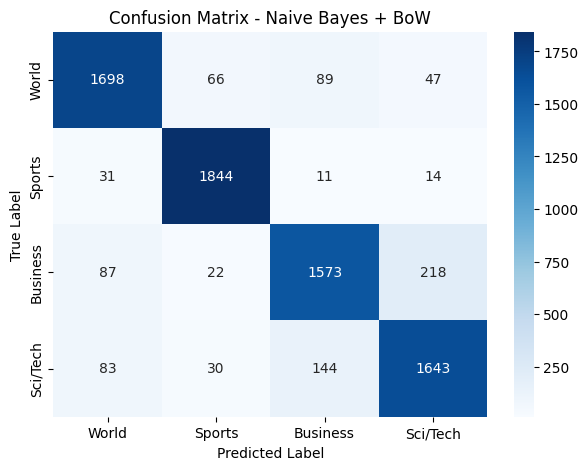

Accuracy     : 0.8892
Macro F1     : 0.8888
Weighted F1  : 0.8888

Training: Logistic Regression + BoW
Training completed in 9.16 seconds
Predicting: Logistic Regression + BoW


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅

Classification Report:
              precision    recall  f1-score   support

       World       0.91      0.89      0.90      1900
      Sports       0.94      0.97      0.96      1900
    Business       0.86      0.86      0.86      1900
    Sci/Tech       0.87      0.87      0.87      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90    

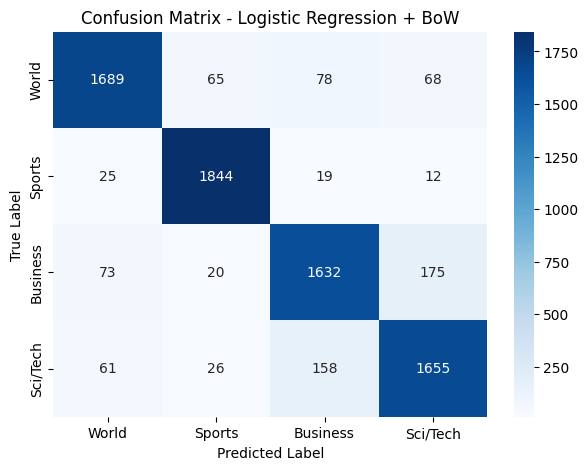

Accuracy     : 0.8974
Macro F1     : 0.8972
Weighted F1  : 0.8972

Training: Linear SVM + BoW
Training completed in 1.48 seconds
Predicting: Linear SVM + BoW


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sports     ❌
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Business   ❌

Classification Report:
              precision    recall  f1-score   support

       World       0.93      0.89      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.88      0.87      0.88      1900
    Sci/Tech       0.87      0.89      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91    

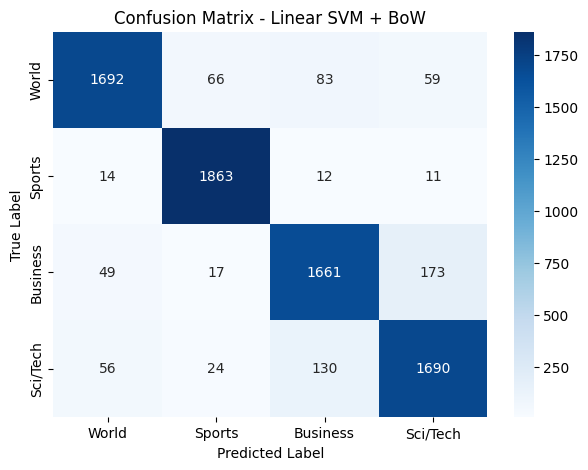

Accuracy     : 0.9087
Macro F1     : 0.9085
Weighted F1  : 0.9085

Training: Naive Bayes + TF-IDF
Training completed in 0.03 seconds
Predicting: Naive Bayes + TF-IDF


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sports     ❌
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅

Classification Report:
              precision    recall  f1-score   support

       World       0.90      0.89      0.90      1900
      Sports       0.94      0.97      0.95      1900
    Business       0.86      0.84      0.85      1900
    Sci/Tech       0.86      0.86      0.86      1900

    accuracy                           0.89      7600
   macro avg       0.89      0.89      0.89    

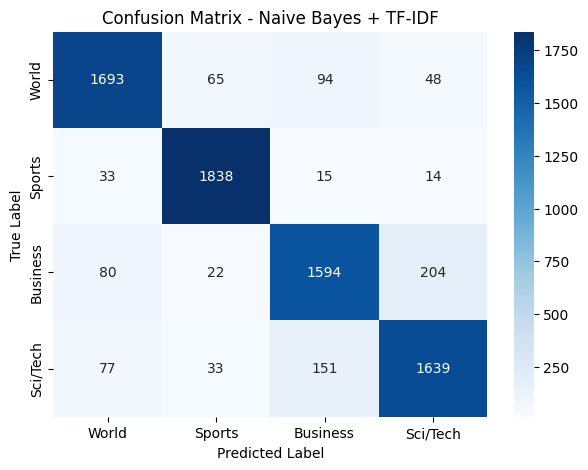

Accuracy     : 0.8900
Macro F1     : 0.8897
Weighted F1  : 0.8897

Training: Logistic Regression + TF-IDF
Training completed in 8.86 seconds
Predicting: Logistic Regression + TF-IDF


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sports     ❌
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.95      0.98      0.96      1900
    Business       0.87      0.87      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91    

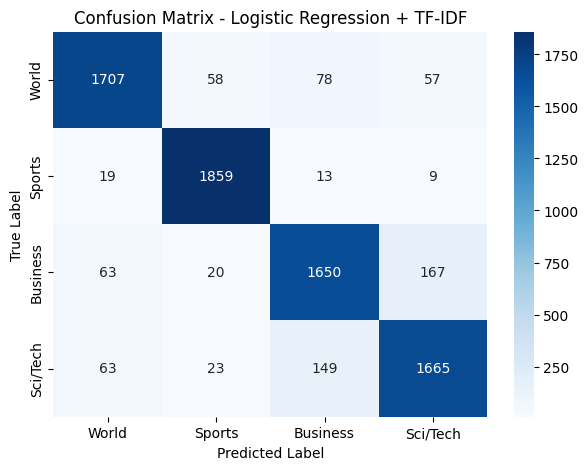

Accuracy     : 0.9054
Macro F1     : 0.9052
Weighted F1  : 0.9052

Training: Linear SVM + TF-IDF
Training completed in 0.88 seconds
Predicting: Linear SVM + TF-IDF


Prediction progress:   0%|          | 0/8 [00:00<?, ?it/s]


First 10 predictions:
Sample  1: Actual = Business   | Predicted = Business   ✅
Sample  2: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  3: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  4: Actual = Sci/Tech   | Predicted = Sports     ❌
Sample  5: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  6: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  7: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  8: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample  9: Actual = Sci/Tech   | Predicted = Sci/Tech   ✅
Sample 10: Actual = Sci/Tech   | Predicted = Business   ❌

Classification Report:
              precision    recall  f1-score   support

       World       0.92      0.89      0.90      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.87      0.86      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90    

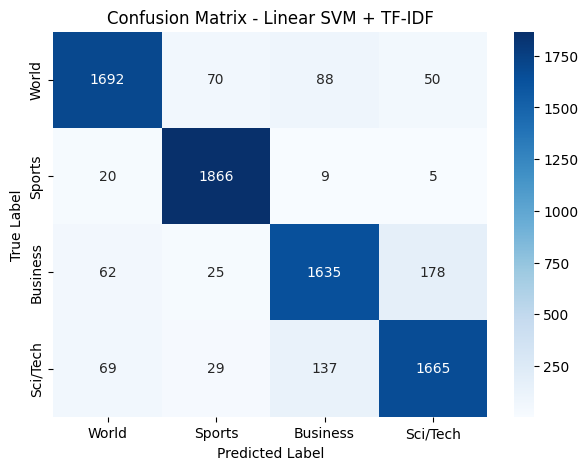

Accuracy     : 0.9024
Macro F1     : 0.9020
Weighted F1  : 0.9020

All traditional ML experiments completed.


In [23]:
# =========================
# Training Traditional ML Models
# =========================

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# =========================
# Ensure required variables exist
# =========================

required_vars = [
    "X_train_bow", "X_test_bow",
    "X_train_tfidf", "X_test_tfidf",
    "y_train", "y_test"
]

missing_vars = [v for v in required_vars if v not in globals()]

if missing_vars:
    raise NameError(
        "Missing variables before training: "
        + ", ".join(missing_vars)
        + "\nPlease run feature loading/conversion cells first."
    )

if "label_map" not in globals():
    label_map = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }

target_names = list(label_map.values())

# =========================
# Define models
# =========================

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ),
    "Linear SVM": SGDClassifier(
        loss="hinge",
        max_iter=1000,
        tol=1e-3,
        random_state=42
    )
}

feature_sets = {
    "BoW": (X_train_bow, X_test_bow),
    "TF-IDF": (X_train_tfidf, X_test_tfidf)
}

results = []
trained_models = {}

# =========================
# Evaluation function
# =========================

def train_and_evaluate(model, Xtr, Xte, ytr, yte, model_name, feature_name):
    print("\n" + "=" * 80)
    print(f"Training: {model_name} + {feature_name}")

    start_time = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - start_time

    print(f"Training completed in {train_time:.2f} seconds")
    print(f"Predicting: {model_name} + {feature_name}")

    batch_size = 1000
    y_pred = []

    for start in tqdm(range(0, Xte.shape[0], batch_size), desc="Prediction progress"):
        end = min(start + batch_size, Xte.shape[0])
        batch_pred = model.predict(Xte[start:end])
        y_pred.extend(batch_pred)

    y_pred = np.array(y_pred)

    acc = accuracy_score(yte, y_pred)
    macro_precision = precision_score(yte, y_pred, average="macro", zero_division=0)
    macro_recall = recall_score(yte, y_pred, average="macro", zero_division=0)
    macro_f1 = f1_score(yte, y_pred, average="macro", zero_division=0)
    weighted_f1 = f1_score(yte, y_pred, average="weighted", zero_division=0)

    print("\nFirst 10 predictions:")
    yte_list = list(yte)

    for i in range(min(10, len(yte_list))):
        actual_label = int(yte_list[i])
        predicted_label = int(y_pred[i])

        actual_name = label_map.get(actual_label, str(actual_label))
        predicted_name = label_map.get(predicted_label, str(predicted_label))

        icon = "✅" if actual_label == predicted_label else "❌"

        print(
            f"Sample {i + 1:>2}: "
            f"Actual = {actual_name:<10} | "
            f"Predicted = {predicted_name:<10} {icon}"
        )

    print("\nClassification Report:")
    print(
        classification_report(
            yte,
            y_pred,
            target_names=target_names,
            zero_division=0
        )
    )

    cm = confusion_matrix(yte, y_pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=target_names,
        yticklabels=target_names
    )
    plt.title(f"Confusion Matrix - {model_name} + {feature_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    result = {
        "Model": model_name,
        "Feature": feature_name,
        "Accuracy": acc,
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Training Time (s)": train_time
    }

    print(f"Accuracy     : {acc:.4f}")
    print(f"Macro F1     : {macro_f1:.4f}")
    print(f"Weighted F1  : {weighted_f1:.4f}")

    return model, result

# =========================
# Run experiments
# =========================

for feature_name, (Xtr, Xte) in feature_sets.items():
    for model_name, model in models.items():
        trained_model, result = train_and_evaluate(
            model=model,
            Xtr=Xtr,
            Xte=Xte,
            ytr=y_train,
            yte=y_test,
            model_name=model_name,
            feature_name=feature_name
        )

        trained_models[f"{model_name}_{feature_name}"] = trained_model
        results.append(result)

print("\nAll traditional ML experiments completed.")




In [24]:
# =========================
# Results table
# =========================

Path("reports").mkdir(parents=True, exist_ok=True)

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(df_results)

,Model,Feature,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s)
0,Linear SVM,BoW,0.908684,0.908741,0.908684,0.908483,0.908483,1.481194
1,Logistic Regression,TF-IDF,0.905395,0.905108,0.905395,0.905154,0.905154,8.857689
2,Linear SVM,TF-IDF,0.902368,0.901949,0.902368,0.901963,0.901963,0.882352
3,Logistic Regression,BoW,0.897368,0.897135,0.897368,0.897156,0.897156,9.164996
4,Naive Bayes,TF-IDF,0.890000,0.889485,0.890000,0.889652,0.889652,0.034643
5,Naive Bayes,BoW,0.889211,0.888641,0.889211,0.888751,0.888751,0.060712


📊 So sánh kết quả

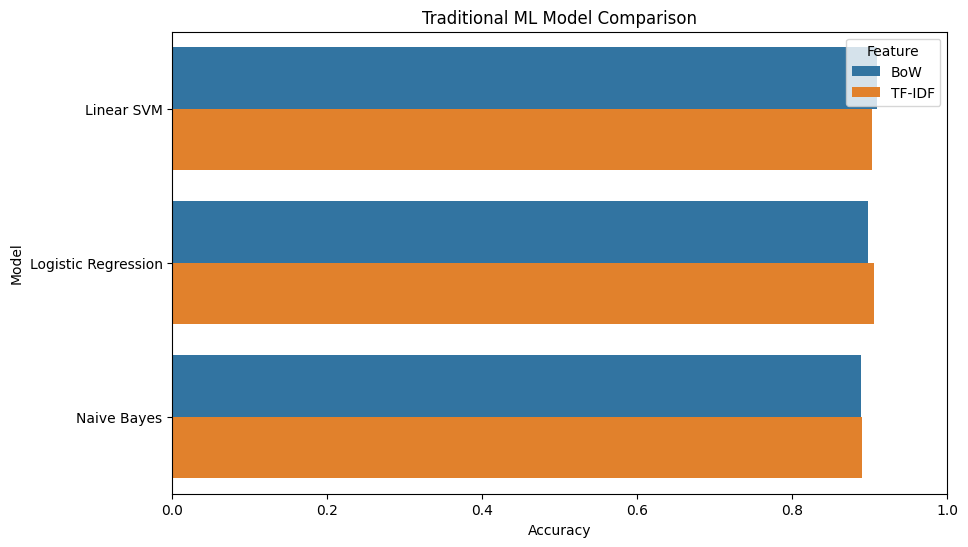

In [25]:
# =========================
# Plot comparison
# =========================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_results,
    x="Accuracy",
    y="Model",
    hue="Feature"
)

plt.title("Traditional ML Model Comparison")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Feature")
plt.show()

In [26]:
# =========================
# Best model
# =========================

best_result = df_results.iloc[0]

print("\nBest traditional model:")
print(f"Model       : {best_result['Model']}")
print(f"Feature     : {best_result['Feature']}")
print(f"Accuracy    : {best_result['Accuracy']:.4f}")
print(f"Macro F1    : {best_result['Macro F1']:.4f}")
print(f"Weighted F1 : {best_result['Weighted F1']:.4f}")


Best traditional model:
Model       : Linear SVM
Feature     : BoW
Accuracy    : 0.9087
Macro F1    : 0.9085
Weighted F1 : 0.9085


🤖 **Pipeline Học Sâu (Deep Learning)**

---



In [31]:
# =========================
# Deep Learning Pipeline Config
# =========================

from pathlib import Path

RUN_DEEP_PIPELINE = True

DEEP_FEATURE_URL = "https://huggingface.co/datasets/hoangminh1110/ML_Assignment252_Feature/resolve/main/ft_deeplearning.zip"

DEEP_ZIP_PATH = Path("ft_deeplearning.zip")
DEEP_FEATURE_DIR = Path("features/deep")
DEEP_FEATURE_DIR.mkdir(parents=True, exist_ok=True)

REPORT_DIR = Path("reports")
REPORT_DIR.mkdir(parents=True, exist_ok=True)

MLP_BATCH_SIZE = 128
MLP_EPOCHS = 8
MLP_LEARNING_RATE = 1e-3
MLP_HIDDEN_DIM = 256
MLP_DROPOUT = 0.3
RANDOM_STATE = 42

print("RUN_DEEP_PIPELINE :", RUN_DEEP_PIPELINE)
print("DEEP_FEATURE_URL  :", DEEP_FEATURE_URL)
print("DEEP_FEATURE_DIR  :", DEEP_FEATURE_DIR)
print("MLP_BATCH_SIZE    :", MLP_BATCH_SIZE)
print("MLP_EPOCHS        :", MLP_EPOCHS)

RUN_DEEP_PIPELINE : True
DEEP_FEATURE_URL  : https://huggingface.co/datasets/hoangminh1110/ML_Assignment252_Feature/resolve/main/ft_deeplearning.zip
DEEP_FEATURE_DIR  : features/deep
MLP_BATCH_SIZE    : 128
MLP_EPOCHS        : 8


In [32]:
# =========================
# Download and Extract Deep Features
# =========================

import os
import zipfile
import urllib.request
import urllib.error
from pathlib import Path

REQUIRED_DEEP_FEATURE_FILES = [
    "features/deep/X_train_bert.npy",
    "features/deep/X_test_bert.npy",
    "features/deep/y_train_bert.npy",
    "features/deep/y_test_bert.npy"
]

def deep_features_ready():
    return all(Path(file).exists() for file in REQUIRED_DEEP_FEATURE_FILES)

if RUN_DEEP_PIPELINE:
    if deep_features_ready():
        print("Deep features already exist locally. Reusing existing files.")
    else:
        print("Deep features not found locally.")
        print("Downloading ft_deeplearning.zip from Hugging Face...")
        print("URL:", DEEP_FEATURE_URL)

        try:
            urllib.request.urlretrieve(DEEP_FEATURE_URL, DEEP_ZIP_PATH)
            print("Download completed:", DEEP_ZIP_PATH)
        except urllib.error.HTTPError as e:
            raise RuntimeError(
                f"Cannot download deep feature file. HTTP status: {e.code}\n"
                f"Please check URL:\n{DEEP_FEATURE_URL}"
            )

        print("Extracting zip file...")

        with zipfile.ZipFile(DEEP_ZIP_PATH, "r") as zip_ref:
            names = zip_ref.namelist()
            print("Zip preview:")
            for name in names[:20]:
                print("-", name)

            # Case 1: zip already contains features/deep/...
            if any(name.startswith("features/deep/") for name in names):
                zip_ref.extractall(".")

            # Case 2: zip contains deep/...
            elif any(name.startswith("deep/") for name in names):
                zip_ref.extractall("features")

            # Case 3: zip directly contains .npy files
            else:
                DEEP_FEATURE_DIR.mkdir(parents=True, exist_ok=True)
                zip_ref.extractall(DEEP_FEATURE_DIR)

        print("\nFiles after extraction:")
        for root, dirs, files in os.walk("features/deep"):
            for file in files[:30]:
                print(os.path.join(root, file))

        if deep_features_ready():
            print("\nDeep features loaded successfully.")
        else:
            missing_files = [
                file for file in REQUIRED_DEEP_FEATURE_FILES
                if not Path(file).exists()
            ]
            raise FileNotFoundError(
                "Missing required deep feature files after extraction:\n"
                + "\n".join(missing_files)
                + "\n\nCheck zip structure and extraction path."
            )
else:
    print("RUN_DEEP_PIPELINE=False. Skip deep feature download.")

Deep features not found locally.
URL: https://huggingface.co/datasets/hoangminh1110/ML_Assignment252_Feature/resolve/main/ft_deeplearning.zip
Download completed: ft_deeplearning.zip
Extracting zip file...
Zip preview:
- X_test_bert.npy
- deep_feature_config.json
- train_bert_progress.json
- X_train_bert.npy
- y_test_bert.npy
- test_bert_progress.json
- y_train_bert.npy

Files after extraction:
features/deep/y_test_bert.npy
features/deep/train_bert_progress.json
features/deep/X_train_bert.npy
features/deep/y_train_bert.npy
features/deep/test_bert_progress.json
features/deep/X_test_bert.npy
features/deep/deep_feature_config.json

Deep features loaded successfully.


In [33]:
# =========================
# Load Deep Learning Features
# =========================

import numpy as np
from pathlib import Path

if not deep_features_ready():
    missing_files = [
        file for file in REQUIRED_DEEP_FEATURE_FILES
        if not Path(file).exists()
    ]
    raise FileNotFoundError(
        "Missing deep feature files:\n" + "\n".join(missing_files)
    )

X_train_bert = np.load("features/deep/X_train_bert.npy")
X_test_bert = np.load("features/deep/X_test_bert.npy")

y_train_bert = np.load("features/deep/y_train_bert.npy")
y_test_bert = np.load("features/deep/y_test_bert.npy")

print("Loaded deep features successfully.")
print("X_train_bert:", X_train_bert.shape, X_train_bert.dtype)
print("X_test_bert :", X_test_bert.shape, X_test_bert.dtype)
print("y_train_bert:", y_train_bert.shape, y_train_bert.dtype)
print("y_test_bert :", y_test_bert.shape, y_test_bert.dtype)

Loaded deep features successfully.
X_train_bert: (120000, 768) float32
X_test_bert : (7600, 768) float32
y_train_bert: (120000,) int64
y_test_bert : (7600,) int64


In [34]:
# =========================
# Prepare Labels for PyTorch
# =========================

import numpy as np

# Fallback label_map nếu chưa có từ pipeline trước
if "label_map" not in globals():
    label_map = {
        1: "World",
        2: "Sports",
        3: "Business",
        4: "Sci/Tech"
    }

print("Original y_train_bert unique labels:", sorted(np.unique(y_train_bert)))
print("Original y_test_bert unique labels :", sorted(np.unique(y_test_bert)))

# CrossEntropyLoss cần label 0-3
if y_train_bert.min() == 1:
    y_train_dl = y_train_bert - 1
    y_test_dl = y_test_bert - 1
    print("Converted labels from 1-4 to 0-3 for PyTorch.")
else:
    y_train_dl = y_train_bert.copy()
    y_test_dl = y_test_bert.copy()
    print("Labels are already in 0-3 format.")

print("PyTorch y_train_dl unique labels:", sorted(np.unique(y_train_dl)))
print("PyTorch y_test_dl unique labels :", sorted(np.unique(y_test_dl)))

target_names = list(label_map.values())
print("Target names:", target_names)

Original y_train_bert unique labels: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Original y_test_bert unique labels : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Converted labels from 1-4 to 0-3 for PyTorch.
PyTorch y_train_dl unique labels: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
PyTorch y_test_dl unique labels : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Target names: ['World', 'Sports', 'Business', 'Sci/Tech']


In [35]:
# =========================
# Create PyTorch DataLoader
# =========================

import torch
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_STATE)

X_train_tensor = torch.tensor(X_train_bert, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_dl, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_bert, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_dl, dtype=torch.long)

train_dataset_mlp = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_mlp = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset_mlp,
    batch_size=MLP_BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset_mlp,
    batch_size=MLP_BATCH_SIZE * 2,
    shuffle=False
)

print("Train dataset size:", len(train_dataset_mlp))
print("Test dataset size :", len(test_dataset_mlp))
print("Input dimension   :", X_train_bert.shape[1])

Train dataset size: 120000
Test dataset size : 7600
Input dimension   : 768


In [36]:
# =========================
# Define MLP Classifier
# =========================

import torch
import torch.nn as nn

class BertEmbeddingMLP(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=256, num_classes=4, dropout=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.network(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

mlp_model = BertEmbeddingMLP(
    input_dim=X_train_bert.shape[1],
    hidden_dim=MLP_HIDDEN_DIM,
    num_classes=4,
    dropout=MLP_DROPOUT
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=MLP_LEARNING_RATE
)

print(mlp_model)

Device: cpu
BertEmbeddingMLP(
  (network): Sequential(
    (0): Linear(in_features=768, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=4, bias=True)
  )
)


In [37]:
# =========================
# Train MLP on DistilBERT Features
# =========================

import time
from tqdm.notebook import tqdm

train_losses = []
train_accuracies = []

start_time = time.time()

for epoch in range(MLP_EPOCHS):
    mlp_model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{MLP_EPOCHS}"
    )

    for batch_X, batch_y in progress_bar:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        logits = mlp_model(batch_X)
        loss = criterion(logits, batch_y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * batch_X.size(0)

        preds = torch.argmax(logits, dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

        progress_bar.set_postfix({
            "loss": loss.item()
        })

    avg_loss = total_loss / total
    train_acc = correct / total

    train_losses.append(avg_loss)
    train_accuracies.append(train_acc)

    print(
        f"Epoch {epoch + 1}/{MLP_EPOCHS} "
        f"- Loss: {avg_loss:.4f} "
        f"- Train Accuracy: {train_acc:.4f}"
    )

deep_train_time = time.time() - start_time

print(f"MLP training completed in {deep_train_time:.2f} seconds.")

Epoch 1/8:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/8 - Loss: 0.3099 - Train Accuracy: 0.8910


Epoch 2/8:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/8 - Loss: 0.2645 - Train Accuracy: 0.9046


Epoch 3/8:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 6/8 - Loss: 0.2322 - Train Accuracy: 0.9172


Epoch 7/8:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 7/8 - Loss: 0.2273 - Train Accuracy: 0.9183


Epoch 8/8:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 8/8 - Loss: 0.2222 - Train Accuracy: 0.9206
MLP training completed in 84.63 seconds.


Deep Learning Pipeline Results
Model   : MLP Neural Network
Feature : DistilBERT Embedding
Accuracy     : 0.9142
Macro F1     : 0.9142
Weighted F1  : 0.9142

Classification Report:
              precision    recall  f1-score   support

       World       0.94      0.90      0.92      1900
      Sports       0.96      0.99      0.98      1900
    Business       0.85      0.91      0.87      1900
    Sci/Tech       0.91      0.86      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.92      0.91      0.91      7600
weighted avg       0.92      0.91      0.91      7600



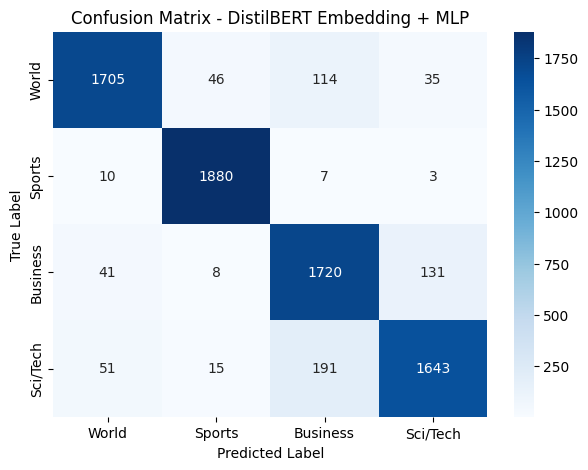

In [38]:
# =========================
# Evaluate Deep Learning Pipeline
# =========================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

mlp_model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)

        logits = mlp_model(batch_X)
        preds = torch.argmax(logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_true.extend(batch_y.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

# Chuyển label 0-3 về 1-4 để đồng bộ với label_map
all_preds_original = all_preds + 1
all_true_original = all_true + 1

deep_accuracy = accuracy_score(all_true_original, all_preds_original)
deep_macro_precision = precision_score(
    all_true_original,
    all_preds_original,
    average="macro",
    zero_division=0
)
deep_macro_recall = recall_score(
    all_true_original,
    all_preds_original,
    average="macro",
    zero_division=0
)
deep_macro_f1 = f1_score(
    all_true_original,
    all_preds_original,
    average="macro",
    zero_division=0
)
deep_weighted_f1 = f1_score(
    all_true_original,
    all_preds_original,
    average="weighted",
    zero_division=0
)

print("Deep Learning Pipeline Results")
print("Model   : MLP Neural Network")
print("Feature : DistilBERT Embedding")
print(f"Accuracy     : {deep_accuracy:.4f}")
print(f"Macro F1     : {deep_macro_f1:.4f}")
print(f"Weighted F1  : {deep_weighted_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_true_original,
        all_preds_original,
        target_names=target_names,
        zero_division=0
    )
)

cm = confusion_matrix(all_true_original, all_preds_original)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix - DistilBERT Embedding + MLP")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

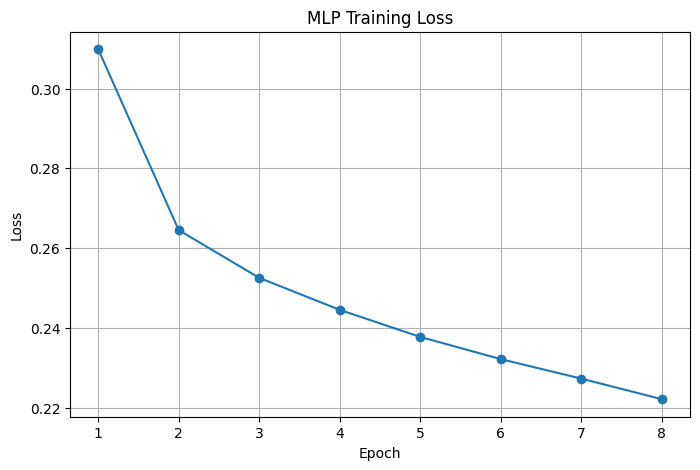

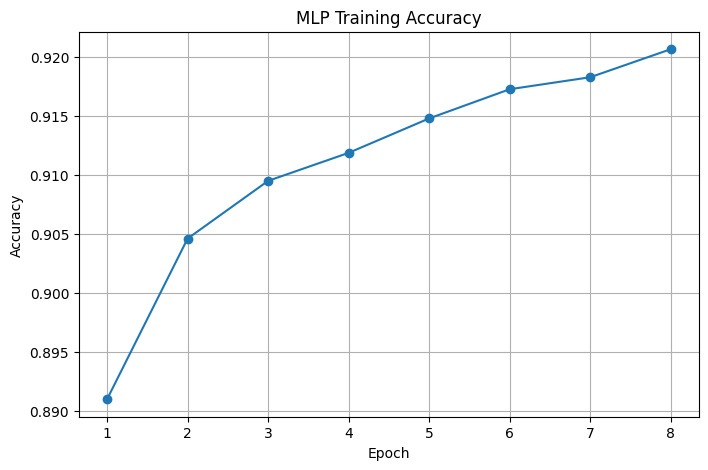

In [39]:
# =========================
# Plot Training Curves
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, MLP_EPOCHS + 1), train_losses, marker="o")
plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(range(1, MLP_EPOCHS + 1), train_accuracies, marker="o")
plt.title("MLP Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [40]:
# =========================
# Save Deep Learning Results
# =========================

import pandas as pd
import json
from pathlib import Path

REPORT_DIR.mkdir(parents=True, exist_ok=True)

deep_result = {
    "Model": "MLP Neural Network",
    "Feature": "DistilBERT Embedding",
    "Accuracy": deep_accuracy,
    "Macro Precision": deep_macro_precision,
    "Macro Recall": deep_macro_recall,
    "Macro F1": deep_macro_f1,
    "Weighted F1": deep_weighted_f1,
    "Training Time (s)": deep_train_time,
    "Pipeline": "Deep Feature Extraction + Neural Network",
    "Train Samples": len(y_train_bert),
    "Test Samples": len(y_test_bert),
    "Input Dim": X_train_bert.shape[1],
    "Epochs": MLP_EPOCHS,
    "Batch Size": MLP_BATCH_SIZE,
    "Learning Rate": MLP_LEARNING_RATE
}

df_deep_result = pd.DataFrame([deep_result])

display(df_deep_result)

df_deep_result.to_csv("reports/deep_learning_results.csv", index=False)

deep_config = {
    "feature_source": DEEP_FEATURE_URL,
    "feature_type": "DistilBERT CLS embedding",
    "classifier": "MLP Neural Network",
    "hidden_dim": MLP_HIDDEN_DIM,
    "dropout": MLP_DROPOUT,
    "epochs": MLP_EPOCHS,
    "batch_size": MLP_BATCH_SIZE,
    "learning_rate": MLP_LEARNING_RATE,
    "train_samples": len(y_train_bert),
    "test_samples": len(y_test_bert),
    "input_dim": int(X_train_bert.shape[1])
}

with open("reports/deep_learning_config.json", "w", encoding="utf-8") as f:
    json.dump(deep_config, f, indent=2)

print("Saved deep learning results to reports/deep_learning_results.csv")
print("Saved deep learning config to reports/deep_learning_config.json")

,Model,Feature,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Pipeline,Train Samples,Test Samples,Input Dim,Epochs,Batch Size,Learning Rate
0,MLP Neural Network,DistilBERT Embedding,0.914211,0.915335,0.914211,0.914217,0.914217,84.632956,Deep Feature Extraction + Neural Network,120000,7600,768,8,128,0.001


Saved deep learning results to reports/deep_learning_results.csv
Saved deep learning config to reports/deep_learning_config.json


,Model,Feature,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1,Training Time (s),Pipeline,Train Samples,Test Samples,Input Dim,Epochs,Batch Size,Learning Rate
0,MLP Neural Network,DistilBERT Embedding,0.914211,0.915335,0.914211,0.914217,0.914217,84.632956,Deep Feature Extraction + Neural Network,120000.0,7600.0,768.0,8.0,128.0,0.001
1,Linear SVM,BoW,0.908684,0.908741,0.908684,0.908483,0.908483,1.481194,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Logistic Regression,TF-IDF,0.905395,0.905108,0.905395,0.905154,0.905154,8.857689,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Linear SVM,TF-IDF,0.902368,0.901949,0.902368,0.901963,0.901963,0.882352,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Logistic Regression,BoW,0.897368,0.897135,0.897368,0.897156,0.897156,9.164996,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Naive Bayes,TF-IDF,0.890000,0.889485,0.890000,0.889652,0.889652,0.034643,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Naive Bayes,BoW,0.889211,0.888641,0.889211,0.888751,0.888751,0.060712,NaN,NaN,NaN,NaN,NaN,NaN,NaN


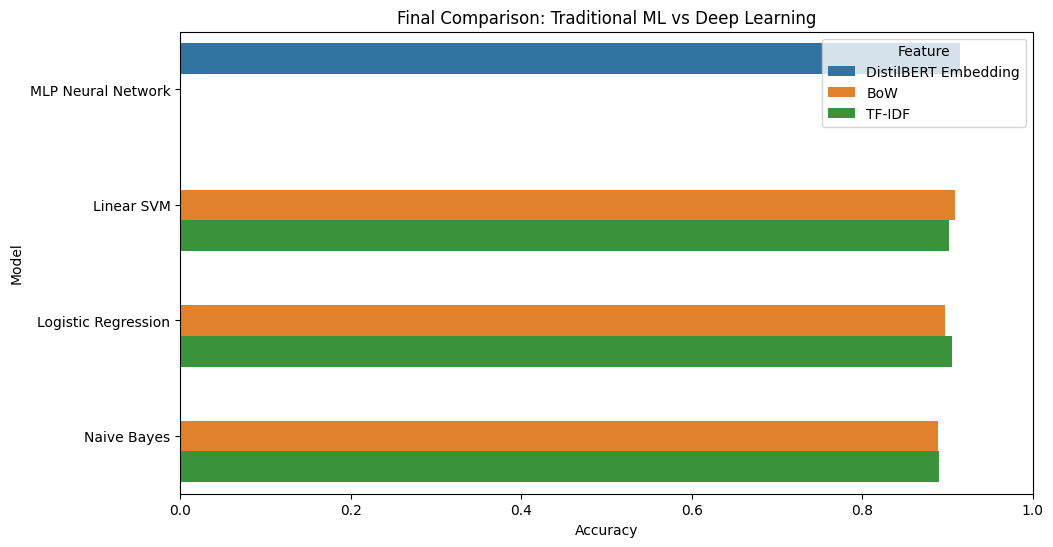

Saved final comparison to reports/final_model_comparison.csv


In [41]:
# =========================
# Final Comparison: Traditional ML vs Deep Learning
# =========================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

if "df_results" in globals():
    df_final_results = pd.concat(
        [df_results, df_deep_result],
        ignore_index=True
    )
else:
    df_final_results = df_deep_result.copy()

df_final_results = df_final_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(df_final_results)

df_final_results.to_csv("reports/final_model_comparison.csv", index=False)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=df_final_results,
    x="Accuracy",
    y="Model",
    hue="Feature"
)

plt.title("Final Comparison: Traditional ML vs Deep Learning")
plt.xlabel("Accuracy")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Feature")
plt.show()

print("Saved final comparison to reports/final_model_comparison.csv")

In [42]:
# =========================
# Best Overall Model
# =========================

best_model_result = df_final_results.iloc[0]

print("Best overall model:")
print(f"Model       : {best_model_result['Model']}")
print(f"Feature     : {best_model_result['Feature']}")
print(f"Accuracy    : {best_model_result['Accuracy']:.4f}")
print(f"Macro F1    : {best_model_result['Macro F1']:.4f}")
print(f"Weighted F1 : {best_model_result['Weighted F1']:.4f}")

Best overall model:
Model       : MLP Neural Network
Feature     : DistilBERT Embedding
Accuracy    : 0.9142
Macro F1    : 0.9142
Weighted F1 : 0.9142
